## Data loading

- Imports the necessary libraries for the Exploratory Data Analysis (EDA)

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

- After downloading and extracting the dataset, reads the data into a DataFrame, which is the standard format for data manipulation and analysis in Python.

In [64]:
df = pd.read_csv(r"C:\Users\vishi\Downloads\Refinery.csv")

In [66]:
df

,Work shift,Type,Refinery,Origin Departure Date,Origin Net Weight,Destination Arrival Date,Destination Net Weight
0,Day shift,VB,Tehran,1398/12/28,24040,1399/01/01,24030
1,Day shift,VB,Tehran,1398/12/28,23720,1399/01/01,23700
2,Day shift,VB,Tehran,1398/12/27,26080,1399/01/01,25980
3,Day shift,VB,Tehran,1398/12/28,23260,1399/01/01,23700
4,Day shift,VB,Tehran,1398/12/29,26380,1399/01/02,26300
...,...,...,...,...,...,...,...
260,Evening shift,Condensate,South Pars,1399/03/19,22696,1399/03/20,22670
261,Evening shift,Condensate,South Pars,1399/03/19,22692,1399/03/20,22690
262,Evening shift,Condensate,South Pars,1399/03/19,22748,1399/03/20,22670
263,Evening shift,Condensate,South Pars,1399/03/19,20574,1399/03/20,20430


### View sample data

- This step is essential for understanding the initial state of the dataset, including column names, data types, and a sample of the data. It helps identify potential issues like missing values or incorrect data types early in the analysis.

In [70]:
df.head()

,Work shift,Type,Refinery,Origin Departure Date,Origin Net Weight,Destination Arrival Date,Destination Net Weight
0,Day shift,VB,Tehran,1398/12/28,24040,1399/01/01,24030
1,Day shift,VB,Tehran,1398/12/28,23720,1399/01/01,23700
2,Day shift,VB,Tehran,1398/12/27,26080,1399/01/01,25980
3,Day shift,VB,Tehran,1398/12/28,23260,1399/01/01,23700
4,Day shift,VB,Tehran,1398/12/29,26380,1399/01/02,26300


### Check structure

- Summary of dataframe structure

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Work shift                265 non-null    object
 1   Type                      265 non-null    object
 2   Refinery                  265 non-null    object
 3   Origin Departure Date     265 non-null    object
 4   Origin Net Weight         265 non-null    int64 
 5   Destination Arrival Date  265 non-null    object
 6   Destination Net Weight    265 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 14.6+ KB


### Get summary stats

- Statistical summary of categorical features

In [78]:
df.describe(include = [object])

,Work shift,Type,Refinery,Origin Departure Date,Destination Arrival Date
count,265,265,265,265,265
unique,3,4,4,41,40
top,Day shift,VB,Shiraz,1399/01/25,1399/01/26
freq,130,206,123,28,30


In [85]:
df.describe(include = [np.number])

,Origin Net Weight,Destination Net Weight
count,265.000000,265.000000
mean,24305.852830,24296.981132
std,1532.788422,1533.901721
min,15050.000000,15110.000000
25%,23300.000000,23410.000000
50%,24380.000000,24340.000000
75%,25250.000000,25230.000000
max,28770.000000,28720.000000


## Data Cleaning

### Find missing values

- Identifying missing data is crucial as it can significantly impact analysis and modeling. Depending on the severity, missing values can be imputed, removed, or handled in other ways. This step helps decide the next course of action regarding data cleaning.

In [90]:
df.isnull().sum()

Work shift                  0
Type                        0
Refinery                    0
Origin Departure Date       0
Origin Net Weight           0
Destination Arrival Date    0
Destination Net Weight      0
dtype: int64

### Understand categories


In [93]:
df.value_counts().sum()

265

### What is the shape of your dataset (rows and columns)?

In [96]:
df.shape

(265, 7)

### Which columns contain missing values?

In [99]:
df.isna().sum()

Work shift                  0
Type                        0
Refinery                    0
Origin Departure Date       0
Origin Net Weight           0
Destination Arrival Date    0
Destination Net Weight      0
dtype: int64

### What are the data types of each column?

In [102]:
df.dtypes

Work shift                  object
Type                        object
Refinery                    object
Origin Departure Date       object
Origin Net Weight            int64
Destination Arrival Date    object
Destination Net Weight       int64
dtype: object

### What is the distribution of key fields like:
### Gender / Category columns
### Target variable (if applicable)
### Any important identifiers or scores


In [105]:
numerical_columns = df.select_dtypes(include = ['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include = ['object']).columns
numerical_columns,categorical_columns

(Index(['Origin Net Weight', 'Destination Net Weight'], dtype='object'),
 Index(['Work shift', 'Type', 'Refinery', 'Origin Departure Date',
        'Destination Arrival Date'],
       dtype='object'))

##  Phase 2: Data Cleaning & Manipulation

### 1. Handle Missing Data

- The goal of this is to ensure that the dataset does not contain duplicate rows, which can skew analysis results and negatively impact the performance of machine learning models. Duplicates may arise due to data entry errors or merging datasets without proper checks

In [110]:
# check for duplicated records
df.duplicated().sum()

1

In [114]:
# Removing duplicate rows
df = df.drop_duplicates()
df.duplicated().sum()

0

In [116]:
# FIX CATEGORICAL INCONSISTENCIES
for col in ['Work shift', 'Type','Refinery']:
    df[col] = df[col].str.strip().str.title()

## Converting Datatypes

In [119]:
!pip install jdatetime

In [121]:
import pandas as pd
import jdatetime

df = pd.read_csv(r"C:\Users\vishi\Downloads\Refinery.csv")


In [123]:
df['Origin Departure Date'] = df['Origin Departure Date'].astype(str).str.strip()
df['Destination Arrival Date'] = df['Destination Arrival Date'].astype(str).str.strip()


In [125]:
# Function to convert Jalali (Persian) date to Gregorian datetime
def jalali_to_gregorian(x):
    if pd.isna(x) or str(x).lower() in ['nan', 'nat', 'none', '']:
        return pd.NaT

    y, m, d = str(x).split('/')
    return jdatetime.date(int(y), int(m), int(d)).togregorian()



In [127]:
# Convert data types
df['Origin Departure Date'] = df['Origin Departure Date'].apply(jalali_to_gregorian)
df['Destination Arrival Date'] = df['Destination Arrival Date'].apply(jalali_to_gregorian)
df['Origin Departure Date'] = pd.to_datetime(df['Origin Departure Date'])
df['Destination Arrival Date'] = pd.to_datetime(df['Destination Arrival Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Work shift                265 non-null    object        
 1   Type                      265 non-null    object        
 2   Refinery                  265 non-null    object        
 3   Origin Departure Date     265 non-null    datetime64[ns]
 4   Origin Net Weight         265 non-null    int64         
 5   Destination Arrival Date  265 non-null    datetime64[ns]
 6   Destination Net Weight    265 non-null    int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 14.6+ KB


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Work shift                265 non-null    object        
 1   Type                      265 non-null    object        
 2   Refinery                  265 non-null    object        
 3   Origin Departure Date     265 non-null    datetime64[ns]
 4   Origin Net Weight         265 non-null    int64         
 5   Destination Arrival Date  265 non-null    datetime64[ns]
 6   Destination Net Weight    265 non-null    int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 14.6+ KB


### Outliers Handling

- Boxplots are a common tool for detecting outliers. In a boxplot, any data points that fall outside of the "whiskers" are typically considered outliers. This visualization helps identify the presence of extreme values in the data

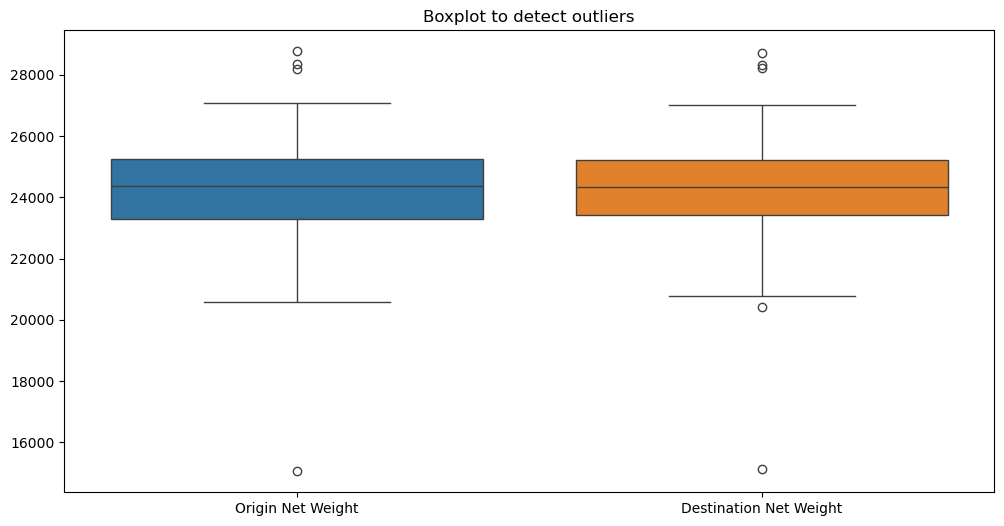

In [133]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['Origin Net Weight', 'Destination Net Weight']])
plt.title('Boxplot to detect outliers')
plt.show()

### Non-Visual Bivariate Analysis

#### CATEGORICAL vs CATEGORICAL
#### Work Shift vs Type distribution

In [137]:
shift_type = pd.crosstab(df['Work shift'],df['Type'])
shift_type

Type,C5+,Condensate,Iso-Recycle,VB
Work shift,,,,
Day shift,12,2,0,116
Evening shift,12,9,4,14
Night shift,12,7,1,76


#### CATEGORICAL vs NUMERICAL
#### Average net weight by work shift

In [140]:
net_weight_shift = df.groupby('Work shift')[['Origin Net Weight','Destination Net Weight']].mean()

In [142]:
net_weight_shift

,Origin Net Weight,Destination Net Weight
Work shift,,
Day shift,24505.038462,24503.000000
Evening shift,23592.871795,23551.025641
Night shift,24325.770833,24321.041667


#### NUMERICAL vs NUMERICAL
#### Correlation between origin and destination net weight

In [145]:
weight_correlation = df[['Origin Net Weight', 'Destination Net Weight']].corr()
weight_correlation

,Origin Net Weight,Destination Net Weight
Origin Net Weight,1.000000,0.998397
Destination Net Weight,0.998397,1.000000


### Insights

- Strong correlation (~0.998) between origin and destination weights

- Day and Night shifts handle heavier loads

- Material handling varies by shift

In [149]:
df.head()

,Work shift,Type,Refinery,Origin Departure Date,Origin Net Weight,Destination Arrival Date,Destination Net Weight
0,Day shift,VB,Tehran,2020-03-18,24040,2020-03-20,24030
1,Day shift,VB,Tehran,2020-03-18,23720,2020-03-20,23700
2,Day shift,VB,Tehran,2020-03-17,26080,2020-03-20,25980
3,Day shift,VB,Tehran,2020-03-18,23260,2020-03-20,23700
4,Day shift,VB,Tehran,2020-03-19,26380,2020-03-21,26300


## Visualization Bivariate Analysis

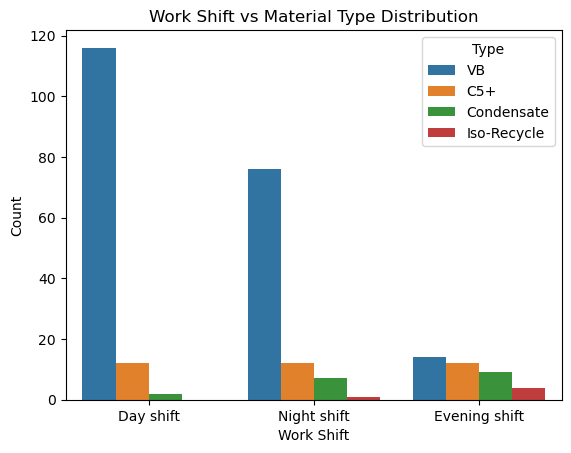

In [152]:
#  categorical vs categorical
sns.countplot(x = 'Work shift', hue = "Type",data = df)
plt.title('Work Shift vs Material Type Distribution')
plt.xlabel('Work Shift')
plt.ylabel('Count')
plt.show()

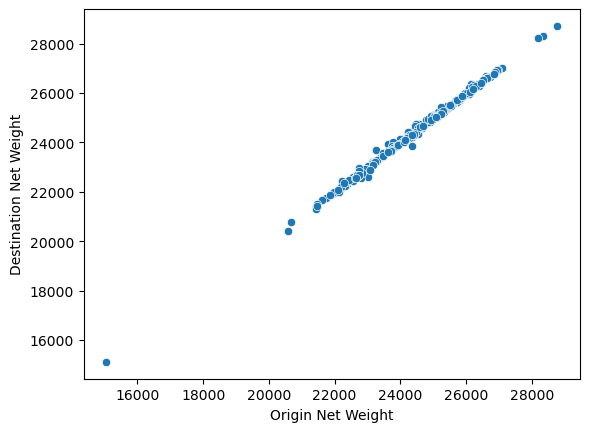

In [154]:
# Scatter plot for numeric features
sns.scatterplot(x='Origin Net Weight', y='Destination Net Weight', data=df)
plt.show()


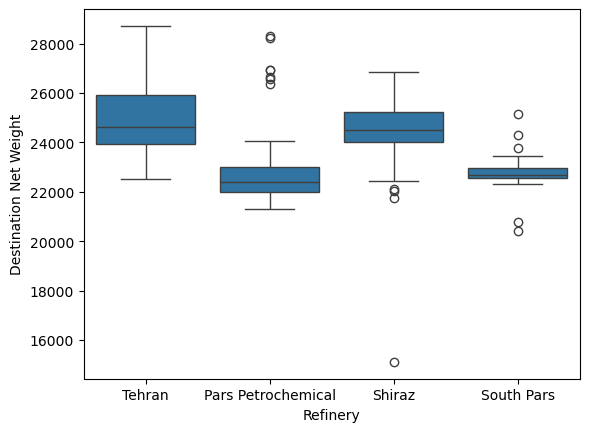

In [156]:
# Box plot for categorical vs numeric
sns.boxplot(x='Refinery', y='Destination Net Weight', data=df)
plt.show()

### Correaltion Matrix

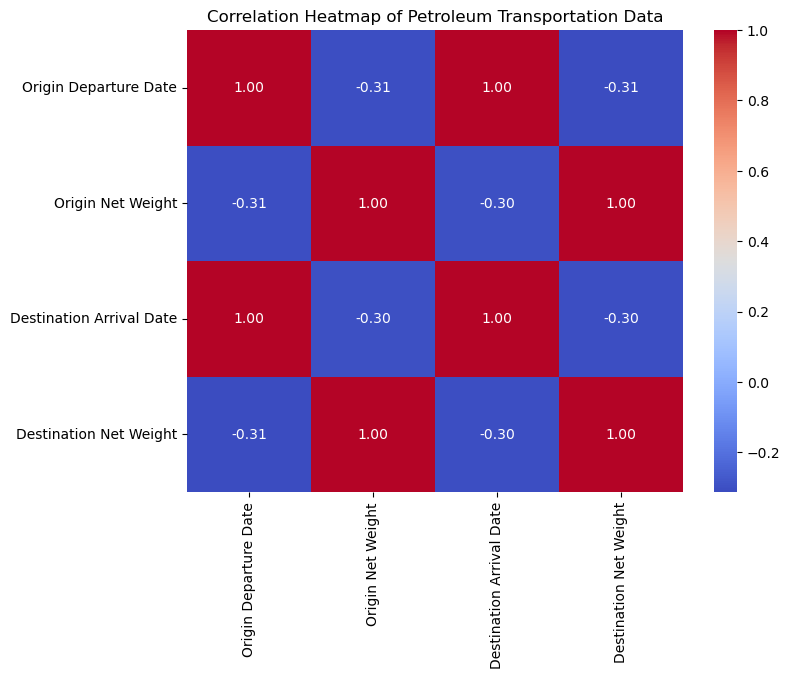

In [175]:
numeric_df = df.select_dtypes(include = ['float64', 'int64', 'datetime64[ns]'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Petroleum Transportation Data')
plt.show()


#### Multivariate Analysis

- This plot is powerful for exploring potential relationships and interactions between multiple variables at once. It also helps in spotting correlations and distribution trends in the data.

In [163]:
df['Origin_Year'] = df['Origin Departure Date'].dt.year
df['Destination_Year'] = df['Destination Arrival Date'].dt.year


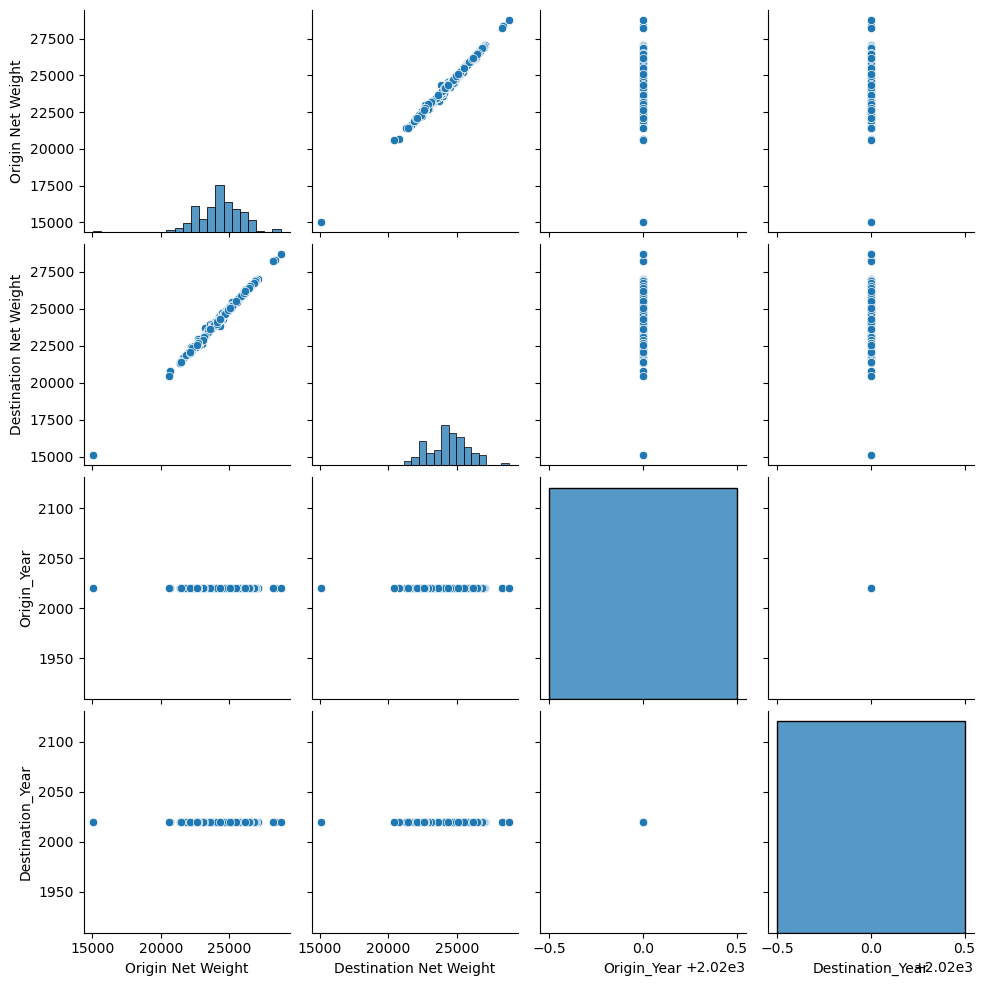

In [181]:
sns.pairplot(df, vars = ['Origin Net Weight', 'Destination Net Weight', 'Origin_Year','Destination_Year' ])
plt.show()